In [1]:
#CLUSTERING JERÁRQUICO.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 

In [2]:
#Carga de la base de datos.
data = pd.read_excel("Amazon.xlsx")
data

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,Adam,205,3,345,235,24,23,26,21,17
1,Anna,9,15,315,33,25,4,42,215,28
2,Bernard,17,26,285,3,43,27,41,26,33
3,Edward,135,5,355,295,18,23,39,195,17
4,Emilia,3,45,48,39,34,46,225,34,43
...,...,...,...,...,...,...,...,...,...,...
95,Teofan,3,8,32,25,7,21,42,17,1
96,Teofil,305,25,46,24,33,28,355,26,45
97,Teofila,1,14,26,25,24,27,42,185,23
98,Teon,155,11,335,34,26,29,42,215,27


In [3]:
#Selección de variables numéricas
data_sin_nombres = data.iloc[:,1:10]
data_sin_nombres

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,205,3,345,235,24,23,26,21,17
1,9,15,315,33,25,4,42,215,28
2,17,26,285,3,43,27,41,26,33
3,135,5,355,295,18,23,39,195,17
4,3,45,48,39,34,46,225,34,43
...,...,...,...,...,...,...,...,...,...
95,3,8,32,25,7,21,42,17,1
96,305,25,46,24,33,28,355,26,45
97,1,14,26,25,24,27,42,185,23
98,155,11,335,34,26,29,42,215,27


In [4]:
#Normalización de los datos
from sklearn.preprocessing import normalize
data_scaled = normalize(data_sin_nombres)
data_scaled[:5]

array([[0.43826336, 0.00641361, 0.73756517, 0.50239946, 0.05130888,
        0.04917101, 0.05558462, 0.04489527, 0.03634379],
       [0.02323527, 0.03872544, 0.81323434, 0.08519598, 0.06454241,
        0.01032679, 0.10843125, 0.55506471, 0.0722875 ],
       [0.05723452, 0.08753514, 0.95951982, 0.01010021, 0.14476966,
        0.09090188, 0.13803618, 0.08753514, 0.11110229],
       [0.25885639, 0.00958727, 0.68069644, 0.56564916, 0.03451419,
        0.04410146, 0.07478074, 0.37390368, 0.03259673],
       [0.01197502, 0.17962533, 0.19160036, 0.15567529, 0.13571692,
        0.18361701, 0.89812667, 0.13571692, 0.17164198]])

In [5]:
#Datos normalizados en DF
data_scaled = pd.DataFrame(data_scaled, columns= data_sin_nombres.columns)
data_scaled.head()

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,0.438263,0.006414,0.737565,0.502399,0.051309,0.049171,0.055585,0.044895,0.036344
1,0.023235,0.038725,0.813234,0.085196,0.064542,0.010327,0.108431,0.555065,0.072287
2,0.057235,0.087535,0.959520,0.010100,0.144770,0.090902,0.138036,0.087535,0.111102
3,0.258856,0.009587,0.680696,0.565649,0.034514,0.044101,0.074781,0.373904,0.032597
4,0.011975,0.179625,0.191600,0.155675,0.135717,0.183617,0.898127,0.135717,0.171642


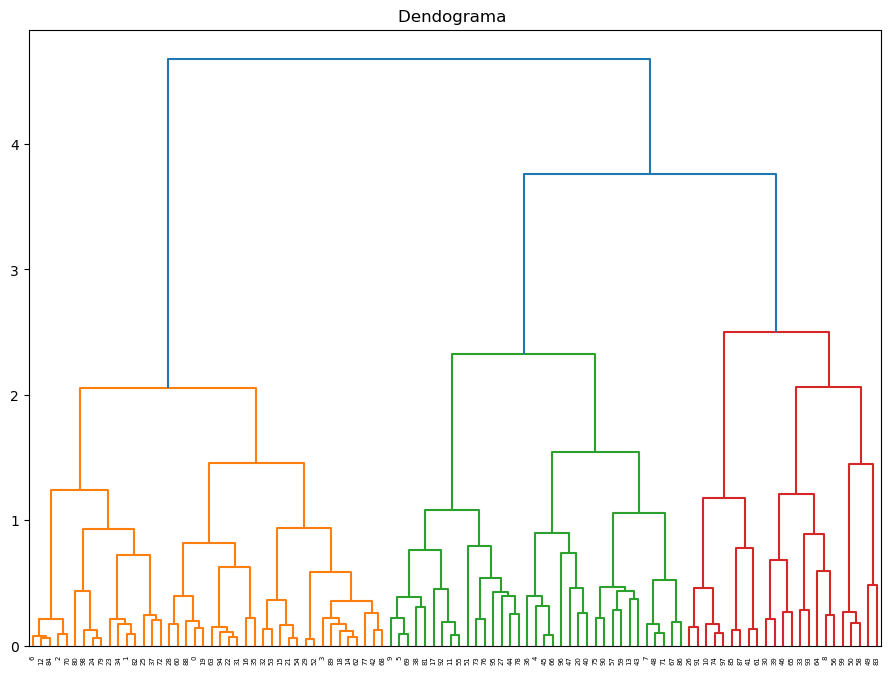

In [6]:
#Construcción del dendograma.
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(11,8))
plt.title("Dendograma ")
dend = shc.dendrogram(shc.linkage(data_scaled,method="ward"))

In [7]:
#Colores del dendograma.
print(dend['color_list'])

['C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C3', 'C0', 'C0']


In [8]:
#Colores únicos en el dendograma
colores_unicos = set(dend['color_list']) #Elementos no repetido de la lista
colores_unicos

{'C0', 'C1', 'C2', 'C3'}

In [9]:
#Número de clusters
num_clusters_optimo = len(colores_unicos)-1
num_clusters_optimo

3

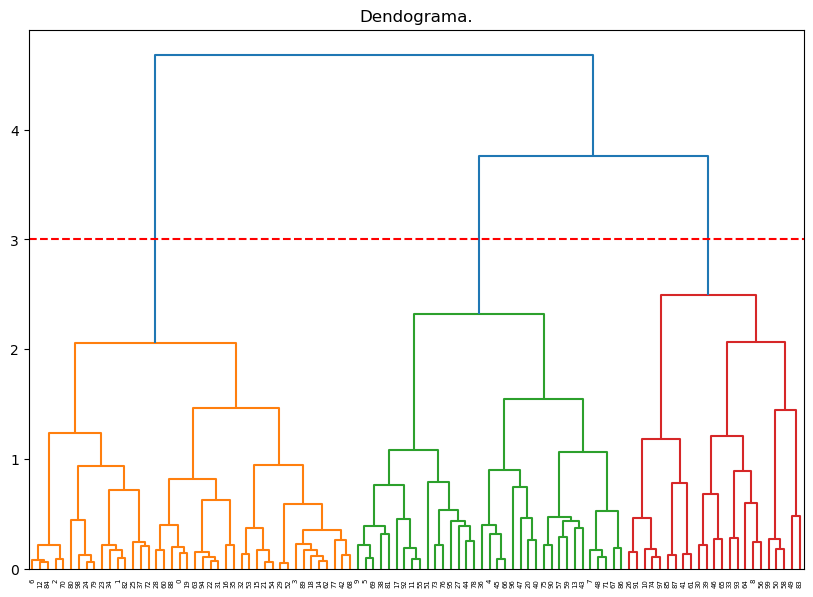

In [10]:
#Corte en el dendograma
plt.figure(figsize=(10,7))
plt.title("Dendograma.")
dend = shc.dendrogram(shc.linkage(data_scaled, method ='ward'))
plt.axhline(y=3,color = 'r',linestyle = '--')

In [11]:
#Formación de los Clusters
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward') 
grupos = cluster.fit_predict(data_scaled)
grupos 

array([1, 1, 1, 1, 2, 2, 1, 2, 0, 2, 0, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 2,
       2, 2, 0, 2, 2, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 0,
       2, 2, 1, 2, 1, 2, 1, 2, 0, 2, 2, 1, 2, 1, 1, 2, 1, 0, 1, 0, 2, 0,
       1, 1, 2, 0, 2, 0, 1, 2, 2, 0, 1, 0])

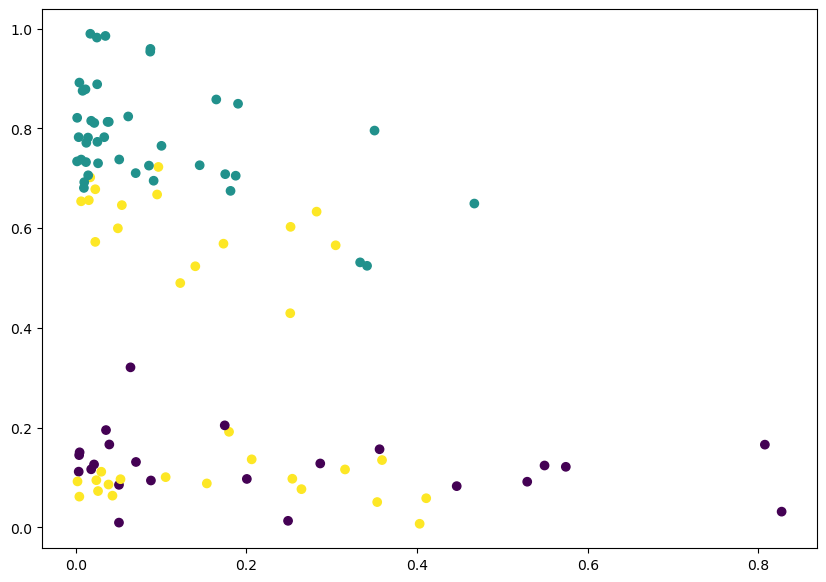

In [12]:
#Visualización de los clusters
plt.figure(figsize=(10,7))
plt.scatter(data_scaled['Precio'],data_scaled['Durabilidad'],c = cluster.labels_)

In [13]:
#Conversión de datos para el ACP
campos = data_scaled.values
campos[:5]

array([[0.43826336, 0.00641361, 0.73756517, 0.50239946, 0.05130888,
        0.04917101, 0.05558462, 0.04489527, 0.03634379],
       [0.02323527, 0.03872544, 0.81323434, 0.08519598, 0.06454241,
        0.01032679, 0.10843125, 0.55506471, 0.0722875 ],
       [0.05723452, 0.08753514, 0.95951982, 0.01010021, 0.14476966,
        0.09090188, 0.13803618, 0.08753514, 0.11110229],
       [0.25885639, 0.00958727, 0.68069644, 0.56564916, 0.03451419,
        0.04410146, 0.07478074, 0.37390368, 0.03259673],
       [0.01197502, 0.17962533, 0.19160036, 0.15567529, 0.13571692,
        0.18361701, 0.89812667, 0.13571692, 0.17164198]])

In [14]:
#ACP
from sklearn import decomposition
pca= decomposition.PCA(n_components=2)
pca.fit(campos)
campos = pca.transform(campos)
campos[:10]

array([[ 0.39993219, -0.06035374],
       [ 0.40829583,  0.06402268],
       [ 0.49703182,  0.35955286],
       [ 0.33996675, -0.18434501],
       [-0.58207751,  0.38797653],
       [-0.1723403 ,  0.52962573],
       [ 0.56528441,  0.33770585],
       [-0.5335887 , -0.06994712],
       [-0.09981604, -0.47165743],
       [-0.22195207,  0.56503313]])

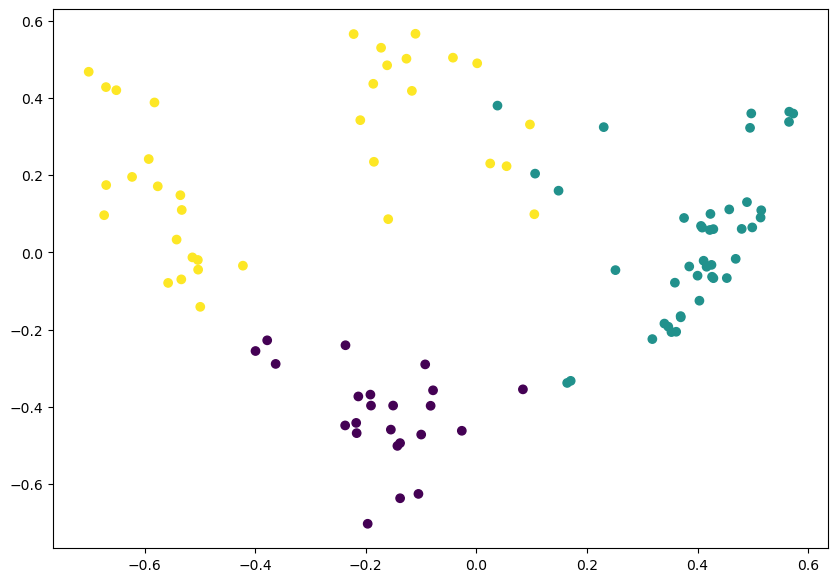

In [15]:
#Representación gráfica de los clusters
plt.figure(figsize=(10,7))
plt.scatter(campos[:,0], campos[:,1],c=cluster.labels_)


In [16]:
#Asignación de los clusters a cada observación
dataframe = pd.DataFrame(grupos, columns=['CJ'])
dataframe[:10]

,CJ
0,1
1,1
2,1
3,1
4,2
5,2
6,1
7,2
8,0
9,2


In [17]:
#Unión de los datos con los clusters
dataframe2 = pd.concat([data_sin_nombres, dataframe], axis=1, join='inner')
dataframe2[:10]

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,CJ
0,205,3,345,235,24,23,26,21,17,1
1,9,15,315,33,25,4,42,215,28,1
2,17,26,285,3,43,27,41,26,33,1
3,135,5,355,295,18,23,39,195,17,1
4,3,45,48,39,34,46,225,34,43,2
5,95,165,395,24,26,19,485,22,3,2
6,23,12,475,33,35,45,38,29,31,1
7,65,21,31,255,28,22,345,215,29,2
8,275,8,47,235,35,3,38,27,48,0
9,2,175,325,3,37,32,435,27,39,2


In [18]:
#Incorporación de los nombres
dataframe2.insert(0, 'Nombre', data.iloc[:, 0].values)
dataframe2[:10]

,Nombre,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,CJ
0,Adam,205,3,345,235,24,23,26,21,17,1
1,Anna,9,15,315,33,25,4,42,215,28,1
2,Bernard,17,26,285,3,43,27,41,26,33,1
3,Edward,135,5,355,295,18,23,39,195,17,1
4,Emilia,3,45,48,39,34,46,225,34,43,2
5,Fabian,95,165,395,24,26,19,485,22,3,2
6,Philip,23,12,475,33,35,45,38,29,31,1
7,Frank,65,21,31,255,28,22,345,215,29,2
8,Xavier,275,8,47,235,35,3,38,27,48,0
9,Gabriel,2,175,325,3,37,32,435,27,39,2


In [19]:
#Identificación del cluster de los clientes
clientes = ['Salome', 'Stephania', 'Lydia']

dataframe2[ dataframe2['Nombre'].isin(clientes)][['Nombre', 'CJ']]

,Nombre,CJ
54,Lydia,1
81,Salome,2
89,Stephania,1


In [20]:
#Calsificación por clusters
cluster_1 = dataframe2[dataframe2['CJ'] == 0]
cluster_2 = dataframe2[dataframe2['CJ'] == 1]

print("CLUSTER 1")
display(cluster_1)

print("CLUSTER 2")
display(cluster_2)

CLUSTER 1


,Nombre,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,CJ
8,Xavier,275,8,47,235,35,3,38,27,48,0
10,Marisol,12,8,44,24,2,28,29,215,17,0
26,Florent,12,75,33,24,19,25,36,185,21,0
30,Herman,15,16,3,265,31,3,4,165,28,0
33,Isadore,17,185,32,285,35,34,42,19,32,0
39,John,12,1,32,225,21,22,44,165,13,0
41,Josephine,295,45,48,39,34,46,225,335,43,0
46,Lawrence,155,95,5,225,26,32,19,245,4,0
49,Leonid,27,105,4,15,38,14,26,19,38,0
50,Lesia,185,35,41,3,21,25,26,25,26,0


CLUSTER 2


,Nombre,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,CJ
0,Adam,205,3,345,235,24,23,26,21,17,1
1,Anna,9,15,315,33,25,4,42,215,28,1
2,Bernard,17,26,285,3,43,27,41,26,33,1
3,Edward,135,5,355,295,18,23,39,195,17,1
6,Philip,23,12,475,33,35,45,38,29,31,1
12,Irene,14,7,405,19,21,14,33,22,24,1
14,Isidore,235,65,495,335,3,26,34,295,39,1
15,Joseph,17,1,485,235,27,17,24,235,34,1
16,Eugene,16,205,285,255,36,29,31,22,23,1
18,Eunice,265,7,485,305,33,39,34,295,39,1


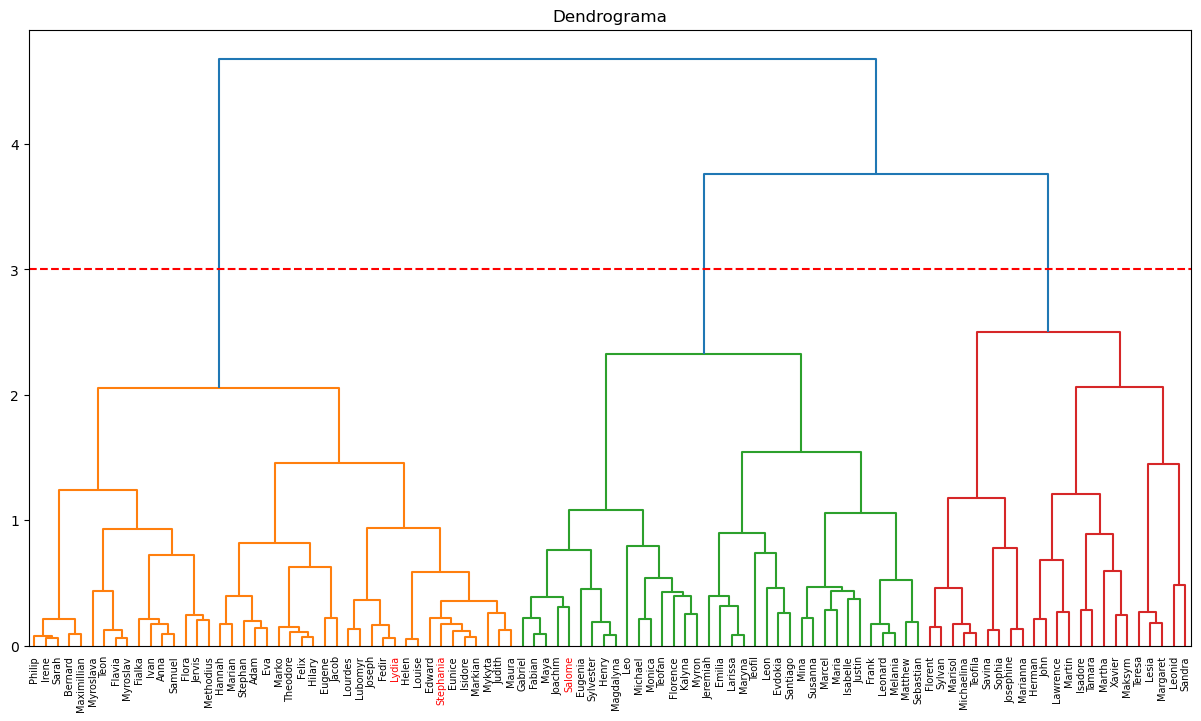

In [21]:
#Dendograma con nombres
plt.figure(figsize=(15,8))
plt.title("Dendrograma")
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'),labels=data.iloc[:,0].values,
                      leaf_rotation=90,leaf_font_size=7)
plt.axhline(y=3, color='r', linestyle='--')

buscar = ['Salome', 'Stephania', 'Lydia']
for nombre in plt.gca().get_xticklabels():
    if nombre.get_text() in buscar:
        nombre.set_color('red')
plt.show()